# Questão 3

In [1]:
from examples.seismic.source import RickerSource, TimeAxis
from examples.seismic import setup_geometry, PointSource, Receiver, plot_velocity
from examples.seismic import SeismicModel, AcquisitionGeometry
try:
    from examples.seismic.stiffness.model import ElasticModel
except:
    from examples.seismic.stiffness.model import ISOSeismicModel as ElasticModel
from examples.seismic.stiffness.utils import C_Matrix, D, S, vec
from devito import *
from examples.seismic.stiffness import iso_elastic_setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from devito import configuration, norm
from IPython.display import display, display_html, HTML

configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


# Preparação do ambiente

## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=8
time_order=2

## Definição do modelo

### Dimensões do modelo

A frequência máxima escolhida foi $30$ $\mathrm{Hz}$, a ordem das derivadas espaciais é $8$ ($F=4$) e a velocidade mínima de propagação é $1000$ $\mathrm{m/s}$. Logo, o espaçamento máximo obedecerá

$$
\begin{aligned}
    \max(\Delta x, \Delta y, \Delta z) &\le \frac{\min(v_P, v_S)}{F f_{\max}}\\
        &= \frac{1000\ \mathrm{m/s}}{4 \times 30\ \mathrm{Hz}}\\
        &= 8 + \frac{1}{3}
\end{aligned}
$$

<!-- , a frequência de pico de uma fonte Ricker será aproximadamente $15$ $\mathrm{Hz}$. -->

Com base nisto, foi escolhido um espaçamento de $\Delta x = \Delta y = \Delta z = 8\ \mathrm{m}$. Visto que o modelo possui dimensões $w \times h \times d = 2000\ \mathrm{m} \times 2000\ \mathrm{m} \times 2000\ \mathrm{m}$, a malha terá
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo x,
$$
n_y = \frac{h}{\Delta y} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo y, e
$$
n_z = \frac{d}{\Delta z} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo z.

In [3]:
# shape = (251, 251, 251)
shape = (20, 20, 20)
spacing = (8, 8, 8)
origin = (0., 0., 0)
nbl=1

### Parâmetros físicos

O modelo possui uma única camada cuja velocidade de propagação das ondas P e S são respectivamente $v_P = 2$ $\mathrm{km/s}$ e $v_S = 1$ $\mathrm{km/s}$, e cuja densidade $\rho$ é $1.8$ $\mathrm{g/cm^3}$.

In [4]:
vp = 2.0 * np.ones(shape, dtype=np.float32) # Velocidade da onda P em km/s
vs = np.ones(shape, dtype=np.float32) # Velocidade da onda S em km/s
rho = 1.8 * np.ones(shape, dtype=np.float32) # Densidade em g/cm^3

In [5]:
model = ElasticModel(vp=vp, vs=vs, b=1/rho, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

In [6]:
def plot_model(model, source=None, receiver=None, colorbar=True, cmap="jet"):
    """
    Esta função exibe os perfis de velocidade da onda P e densidade.
    """
    domain_size = 1.e-3 * np.array(model.domain_size)
    origin = 1.e-3 * np.array(model.origin)
    extent = [origin[0], origin[0] + domain_size[2],
              origin[1] + domain_size[2], origin[1]]

    slices = tuple(slice(model.nbl, -model.nbl) for _ in range(3))

    fig, axes = plt.subplots(1,3, figsize=(22,5))
    ax_vp = axes[0]
    ax_vs = axes[1]
    ax_rho = axes[2]
    
    vp = model.vp.data[slices]
    vs = model.vs.data[slices]
    rho = 1/model.b.data[slices]

    plot_vp = ax_vp.imshow(np.transpose(vp[:,vp.shape[0]//2,:]), animated=True, cmap='jet',
                      vmin=np.min(vp), vmax=np.max(vp),
                      extent=extent)
    ax_vp.set_xlabel('X position (km)')
    ax_vp.set_ylabel('Depth (km)')
    

    plot_vs = ax_vs.imshow(np.transpose(vs[:,vp.shape[0]//2,:]), animated=True, cmap='magma',
                      vmin=np.min(vs), vmax=np.max(vs),
                      extent=extent)
    ax_vs.set_xlabel('X position (km)')
    # ax_vp.set_ylabel('Depth (km)')


    plot_rho = ax_rho.imshow(np.transpose(rho[:,vp.shape[0]//2,:]), animated=True, cmap='cividis',
                      vmin=np.min(rho), vmax=np.max(rho),
                      extent=extent)
    ax_rho.set_xlabel('X position (km)')
    # ax_vp.set_ylabel('Depth (km)')


    for ax in axes:
        # Plot source points, if provided
        if receiver is not None:
            ax.scatter(1e-3*receiver[:, 0], 1e-3*receiver[:, 1],
                        s=25, c='green', marker='D')

        # Plot receiver points, if provided
        if source is not None:
            ax.scatter(1e-3*source[:, 0], 1e-3*source[:, 1],
                        s=25, c='red', marker='o')
        
        # Ensure axis limits
        ax.set_xlim(origin[0], origin[0] + domain_size[0])
        ax.set_ylim(origin[1] + domain_size[1], origin[1])


    # Create aligned colorbar on the right
    if colorbar:
        divider = make_axes_locatable(ax_vp)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vp, cax=cax)
        cbar.set_label('P Velocity (km/s)')
        
        divider = make_axes_locatable(ax_vs)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vs, cax=cax)
        cbar.set_label('S Velocity (km/s)')

        divider = make_axes_locatable(ax_rho)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_rho, cax=cax)
        cbar.set_label('Density (g/cm$^3$)')

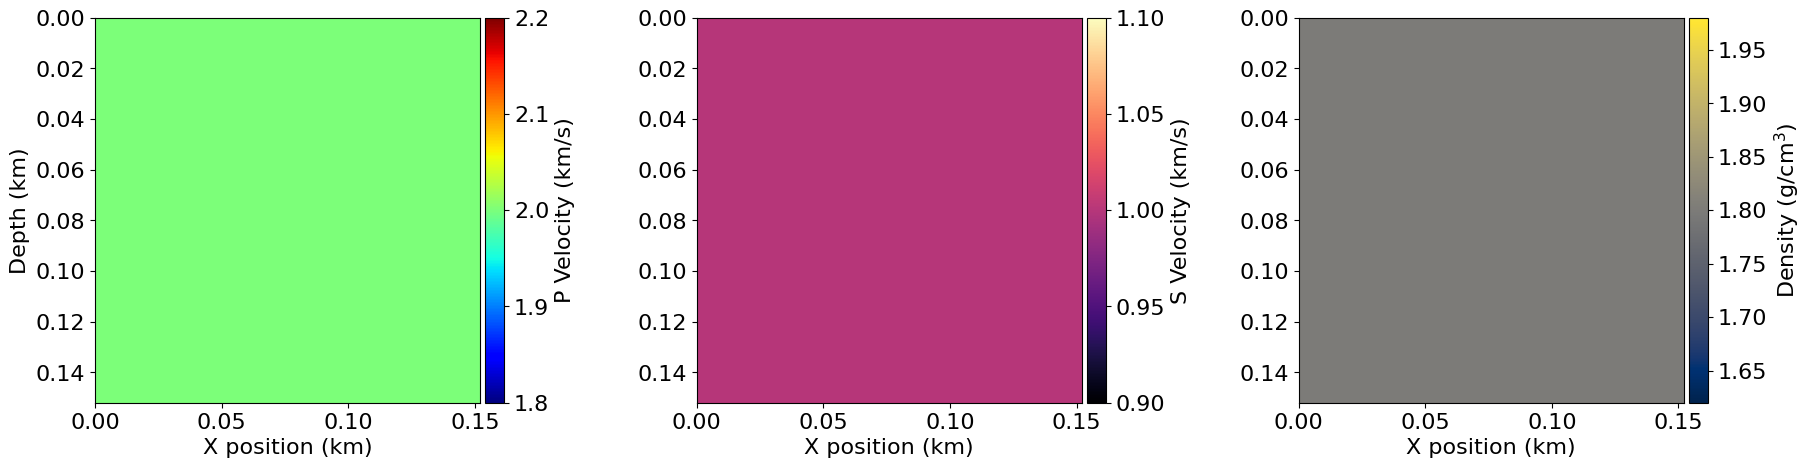

In [7]:
plot_model(model)

## Parâmetros da aquisição

### Tempo de aquisição

O período de aquisição inicia em $t_0 = 0$ $\mathrm{ms}$ e termina em $t_n = 2000$ $\mathrm{ms}$. O comprimento do passo temporal, $\Delta t$, foi escolhido como o $\Delta t_{\text{crítico}}$ que, embora tenha sido calculado por outro método, satisfaz a condição de estabilidade:
$$
\Delta t \le \frac{1}{\max(v_P)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta z^2}}}
$$

In [8]:
t0 = 0.  # ms
tn = 2000. # ms
dt = model.critical_dt

time_range = TimeAxis(start=t0, stop=tn, step=dt)

### Geometria

Como o valor mínimo do campo de velocidade é $1.0\ \mathrm{km/s}$, o espaçamento do modelo é $\Delta x = \Delta z = 8 \mathrm{m}$ e a ordem do operador de diferenças finitas para as derivadas espaciais é igual a $8$ ($F = 4$), a frequência máxima $f_{\mathrm{max}}$ da onda propagada deve satisfazer
$$
\begin{aligned}
f_{\mathrm{max}} &\le \frac{\min{v_P, v_S}}{F\max{\Delta x, \Delta z}}\\
    &= \frac{1.0\ \mathrm{km/s}}{4 \times 8\ \mathrm{m}}\\
    &= 0.03125\ \mathrm{kHz}
\end{aligned}
$$
A assinatura da fonte será a fonte de Ricker, que possui uma frequência de pico $f_{\mathrm{peak}} \approx \dfrac{1}{3} f_{\mathrm{max}}$. Com base nisto, foi escolhida uma frequência máxima de $0.030\ \mathrm{kHz}$, resultando numa frequência de pico igual a $0.010\ \mathrm{kHz}$.

In [9]:
# Frequência de pico da fonte
f0 = 0.010

In [10]:
zero_coords = np.array([[0,0,0]], dtype=model.dtype) # Para zerar as coordenadas da fonte e dos receptores da geometria.
geometry = AcquisitionGeometry(model, zero_coords, zero_coords, t0, tn)
geometry.resample(dt)

time_range = geometry.time_axis

A fonte está posicionada no centro do modelo.

In [11]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

src.coordinates.data[0, :] = np.array(model.domain_size) * .5

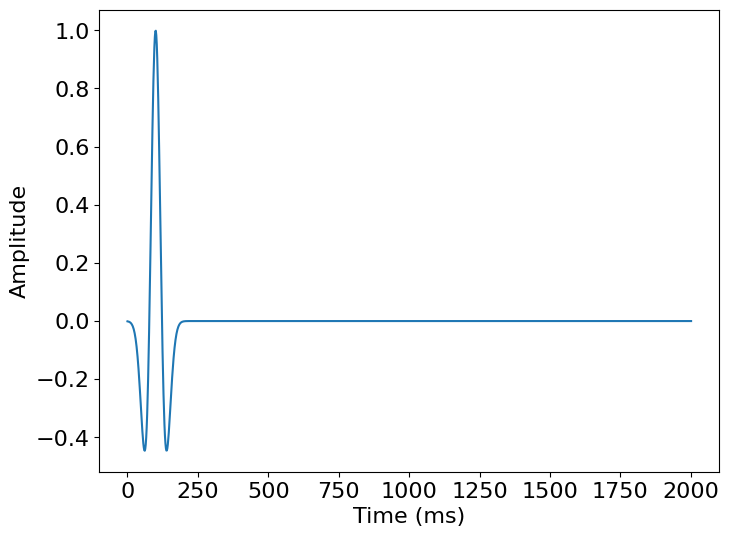

In [12]:
src.show() # Assinatura da fonte

# Resolução da alternativa a)

### Definição da equação da onda elástica de 2ª ordem

Aqui é definida no *Devito* a equação

$$
\rho\frac{\partial^2 \mathbf{u}}{\partial t^2} - DCD^T\mathbf{u} = \mathbf{F}
$$

em que:

- $\mathbf{u}$ é o campo de deslocamento de partícula;
- $C$ é a matriz de rigidez;
- $D$ é a matriz de derivadas espaciais;
- $\mathbf{F}$ é o termo fonte;

In [13]:
C = C_Matrix(model,'vp-vs-rho')

In [14]:
# tau = vec(TensorTimeFunction(name='tau', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt))
# v = VectorTimeFunction(name='v', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt)
u = VectorTimeFunction(name='u', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt, staggered=[NODE, NODE, NODE])

In [15]:
# Equações da onda elástica de 2ª ordem
EDP = model.rho * u.dt2 - D(C*S(u))

In [16]:
# Expressão para o campo de ondas futuro, P(r, t + dt)

stencil = Eq(u.forward, solve(EDP, u.forward))
stencil

Eq(Vector(u_x(time + dt, x, y, z), u_y(time + dt, x, y, z), u_z(time + dt, x, y, z)), Vector(dt**2*(-rho*(-2.0*u_x(time, x, y, z)/dt**2 + u_x(time - dt, x, y, z)/dt**2) + Derivative(rho*(Derivative(u_x(time, x, y, z), y) + Derivative(u_y(time, x, y, z), x))*vs(x, y, z)**2, y) + Derivative(rho*(Derivative(u_x(time, x, y, z), z) + Derivative(u_z(time, x, y, z), x))*vs(x, y, z)**2, z) + Derivative(rho*vp(x, y, z)**2*Derivative(u_x(time, x, y, z), x) + (rho*vp(x, y, z)**2 - 2*rho*vs(x, y, z)**2)*Derivative(u_y(time, x, y, z), y) + (rho*vp(x, y, z)**2 - 2*rho*vs(x, y, z)**2)*Derivative(u_z(time, x, y, z), z), x))/rho, dt**2*(-rho*(-2.0*u_y(time, x, y, z)/dt**2 + u_y(time - dt, x, y, z)/dt**2) + Derivative(rho*(Derivative(u_x(time, x, y, z), y) + Derivative(u_y(time, x, y, z), x))*vs(x, y, z)**2, x) + Derivative(rho*(Derivative(u_y(time, x, y, z), z) + Derivative(u_z(time, x, y, z), y))*vs(x, y, z)**2, z) + Derivative(rho*vp(x, y, z)**2*Derivative(u_y(time, x, y, z), y) + (rho*vp(x, y, z)**2

Com base na expressão acima para o campo $\mathbf{u}(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte possui um coeficiente igual a $\frac{1}{\rho}\Delta t^2$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\frac{1}{\rho}\Delta t^2 S(\mathbf{x}, t)$.

In [17]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term_xx = src.inject(u[0].forward, expr = 1/model.rho * s**2 * src)
src_term_yy = src.inject(u[1].forward, expr = 1/model.rho * s**2 * src)

src_term = src_term_xx + src_term_yy

### Criação do operador de diferenças finitas

In [18]:
# Criação do operador do Devito
op = Operator([stencil] + src_term, subs=model.spacing_map)

In [19]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.38803999999999983, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.00024499999999999945, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

### Plotagem do campo de ondas

In [20]:
def plot_wavefield_slice(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None, y=-1):
    """
    Exibe o campo de onda em 4 instantes distribuídos em um período determinado por `t0` e `tn`
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))
    y_idx = y
    if y_idx < 0 or y_idx >= model.shape[1]:
        y_idx = model.shape[1]//2

    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, y_idx, model.nbl:-model.nbl].T,
                              cmap="seismic", vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")
            
        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)

        ax.text(
        plt_extent[0] + (plt_extent[2] - plt_extent[0])*0.05, 
        plt_extent[1] + (plt_extent[3] - plt_extent[1])*0.05
            , '$y=%.2f \\mathrm{m}$' % (y_idx * model.spacing[1] + model.origin[1]))
        
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax
    
    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

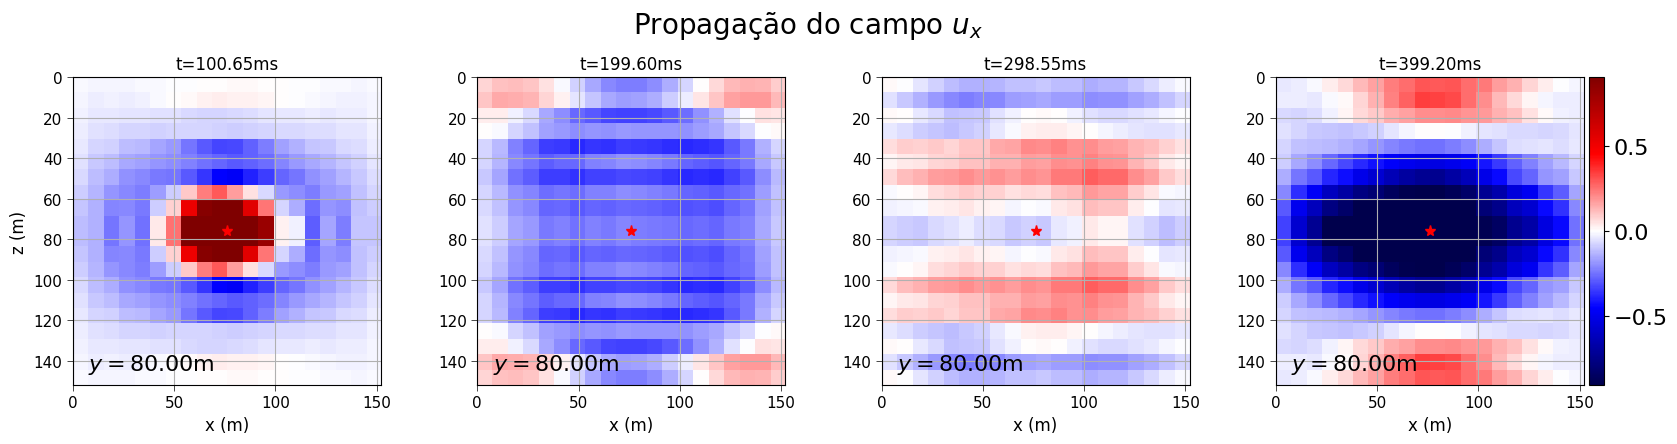

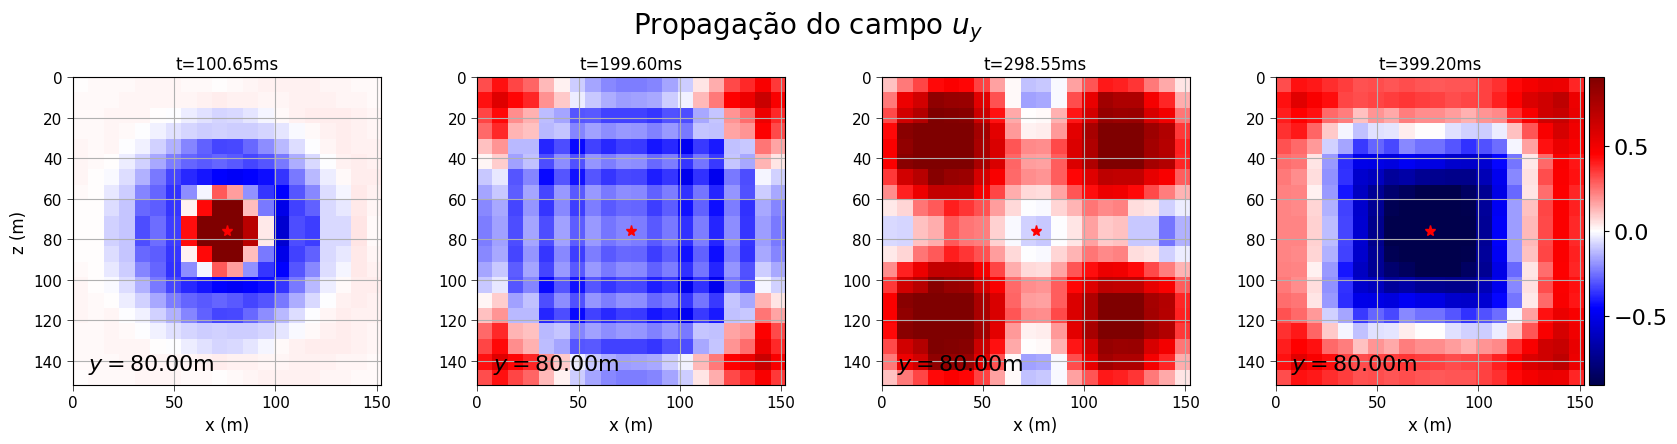

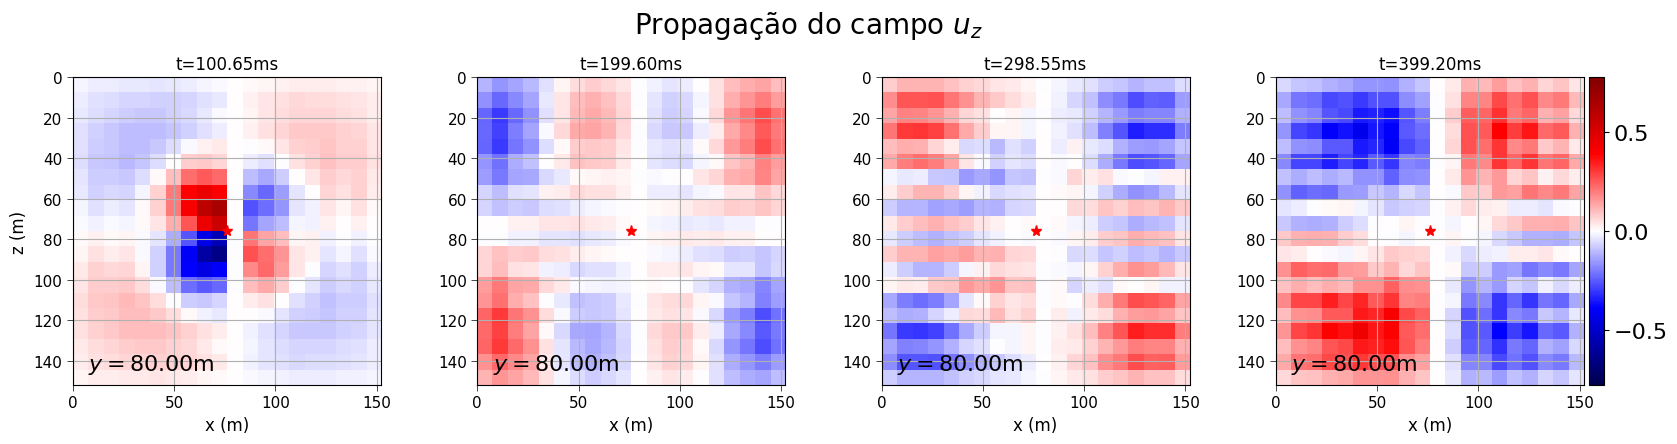

In [21]:
plot_wavefield_slice(u[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{x}$', t0=100, tn=400)
plot_wavefield_slice(u[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{y}$', t0=100, tn=400)
plot_wavefield_slice(u[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{z}$', t0=100, tn=400)

In [ ]:
def rot(u, name):
    rotu = VectorTimeFunction(name=f'rot_{name}', grid=u.grid, space_order=u.space_order, save=u[0].save)
    components=[
        u[2].dy - u[1].dz, u[0].dz - u[2].dx, u[1].dx - u[0].dy
    ]

    Operator([
        Eq(rotu[0], components[0]),
        Eq(rotu[1], components[1]),
        Eq(rotu[2], components[2])
    ])()

    return rotu

In [23]:
divu = TimeFunction(name='divu', grid=model.grid, space_order=space_order, save=geometry.nt)
rotu = VectorTimeFunction(name='rotu', grid=model.grid, space_order=space_order, save=geometry.nt)

Operator([Eq(divu, div(u))])()
Operator([Eq(rotu, rot(u, 'u'))])()

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.048334999999999996, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

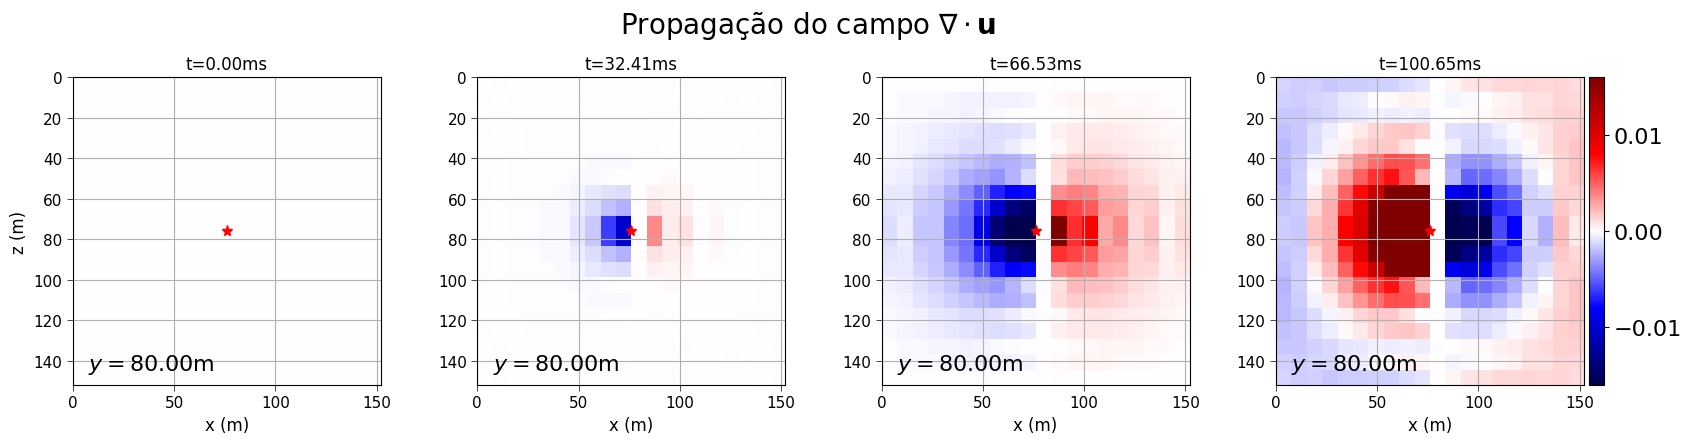

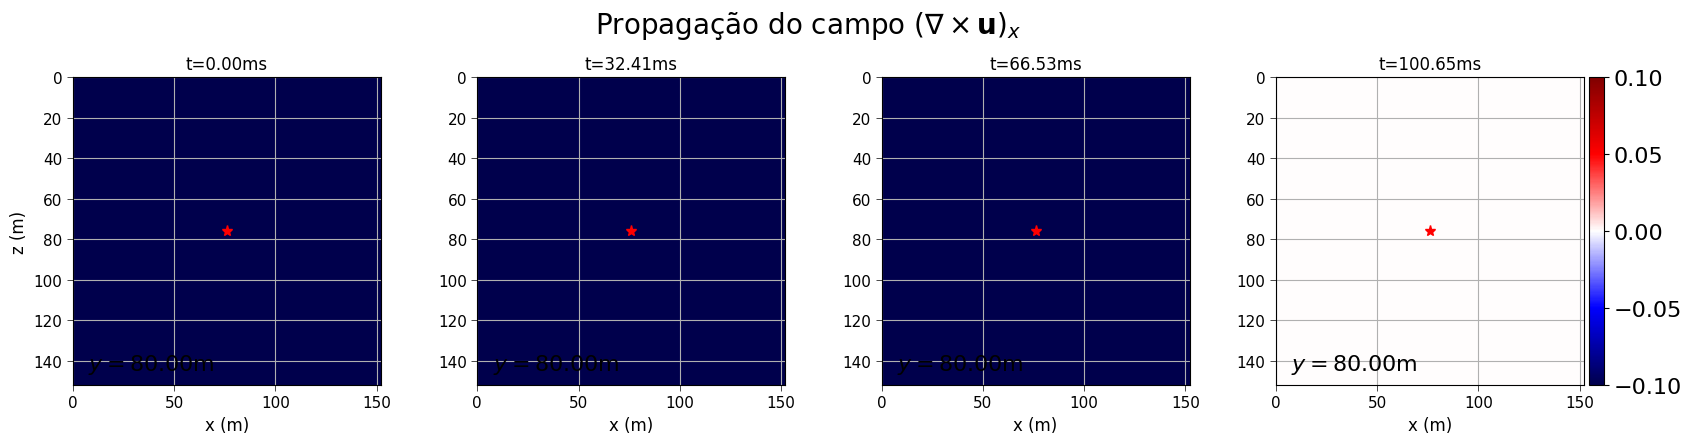

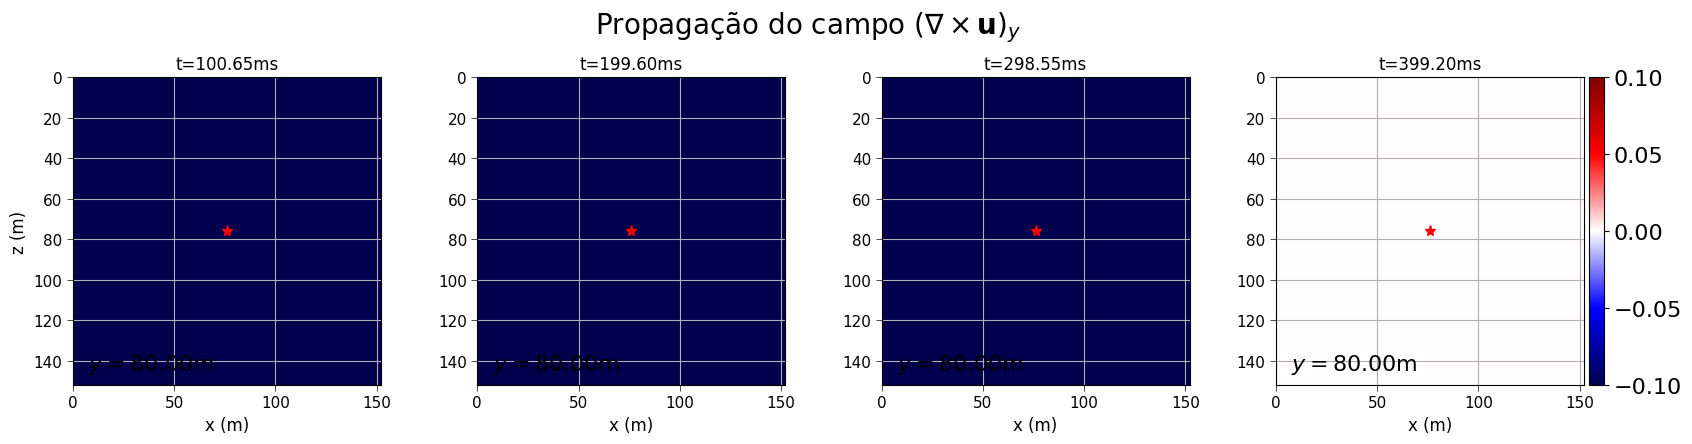

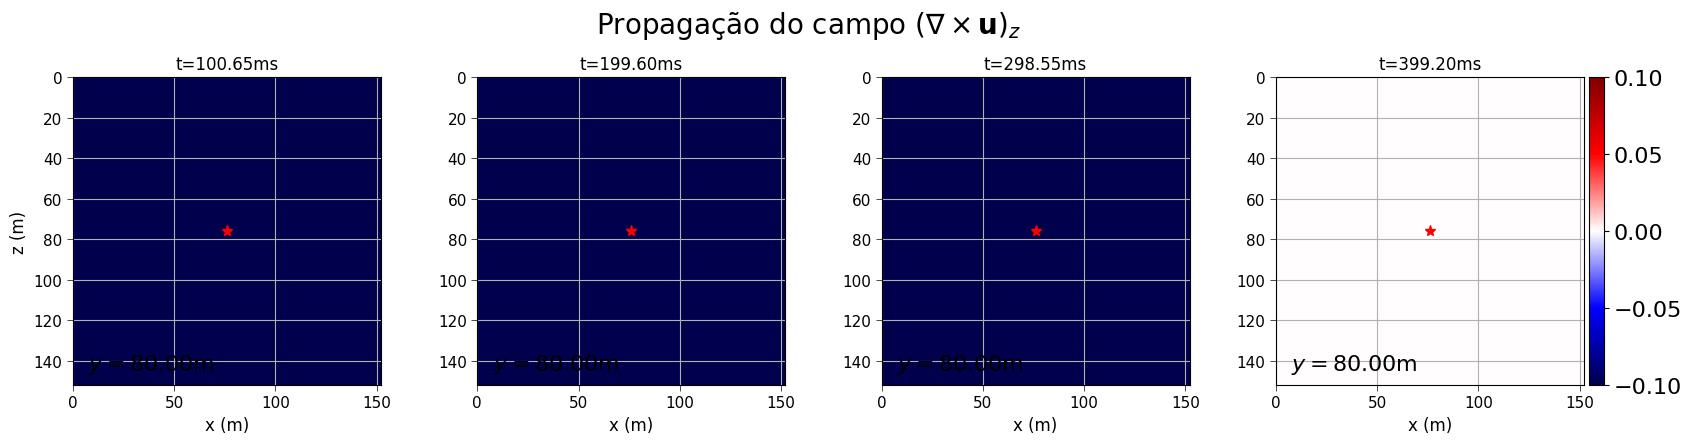

In [32]:
plot_wavefield_slice(divu, geometry, src.coordinates.data[0], model, 'Propagação do campo $\\nabla \\cdot \\mathbf{u}$', t0=0, tn=100)
plot_wavefield_slice(rotu[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_x$', t0=0, tn=100)
plot_wavefield_slice(rotu[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_y$', t0=100, tn=400)
plot_wavefield_slice(rotu[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_z$', t0=100, tn=400)